# Predicția Distanței de Aterizare a Baloanelor Meteorologice
## Machine Learning — Modele de Regresie

Acest notebook antrenează și evaluează modele ML pentru a prezice distanța de aterizare
a unui balon meteorologic față de punctul de lansare.


## 1. Import librării

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style="whitegrid")

print("Librarii incarcate!")
print("Instaleaza xgboost daca lipseste: pip install xgboost")


Librarii incarcate!
Instaleaza xgboost daca lipseste: pip install xgboost


## 2. Încărcare date

In [2]:
# Incarca target-ul calculat in EDA
df = pd.read_csv(r"D:\User\Documents\GitHub\ML---proiect\Date\lansari_cu_target.csv")

print(f"Date incarcate: {len(df):,} lansari")
print(f"\nColoane disponibile:")
print(df.dtypes)
print(f"\nPrimele randuri:")
df.head()


Date incarcate: 54,641 lansari

Coloane disponibile:
serial                object
lat_lansare          float64
lon_lansare          float64
lat_aterizare        float64
lon_aterizare        float64
alt_max_m            float64
dist_aterizare_km    float64
nr_puncte              int64
durata_min           float64
dtype: object

Primele randuri:


,serial,lat_lansare,lon_lansare,lat_aterizare,lon_aterizare,alt_max_m,dist_aterizare_km,nr_puncte,durata_min
0,001---2-10411,44.130828,21.663303,44.133544,21.550680,29580.8,8.993346,3,11.366667
1,001---2-11036,45.128635,20.408517,45.381381,20.275123,30850.6,29.981061,3,52.066667
2,001---2-11042,45.034175,20.753280,45.175376,20.641925,32977.3,17.969252,3,57.900000
3,001---2-11044,44.930011,20.980106,45.015293,20.801977,30686.8,16.919585,3,43.883333
4,001---2-11046,45.213790,21.334854,45.220306,21.097549,30917.3,18.601799,3,28.933333


In [3]:
# Incarca si datele SondeHub pentru features suplimentare
df_sh = pd.read_csv(r"D:\User\Documents\GitHub\ML---proiect\Date\sondehub_europe_all.csv")
df_sh['datetime'] = pd.to_datetime(df_sh['datetime'], utc=True, errors='coerce')
df_sh = df_sh[df_sh['datetime'].dt.year >= 2022]

# Calculeaza features agregate per lansare
features_sh = df_sh.groupby('serial').agg(
    vel_h_mean  = ('vel_h', 'mean'),
    vel_h_max   = ('vel_h', 'max'),
    vel_v_mean  = ('vel_v', 'mean'),
    vel_v_max   = ('vel_v', 'max'),
    temp_min    = ('temp',  'min'),
    heading_mean= ('heading','mean'),
    nr_puncte   = ('alt',   'count'),
).reset_index()

# Merge cu df_target
df = df.merge(features_sh, on='serial', how='left')

# Adauga luna si anotimp din primul punct al lansarii
primul_punct = df_sh.sort_values('datetime').groupby('serial').first().reset_index()[['serial','datetime']]
df = df.merge(primul_punct, on='serial', how='left')
df['datetime'] = pd.to_datetime(df['datetime'], utc=True, errors='coerce')
df['luna']     = df['datetime'].dt.month
df['anotimp']  = df['luna'].map({
    12:0, 1:0, 2:0,   # Iarna
    3:1,  4:1, 5:1,   # Primavara
    6:2,  7:2, 8:2,   # Vara
    9:3, 10:3, 11:3   # Toamna
})

print(f"Dataset final: {len(df):,} lansari, {len(df.columns)} coloane")
df.head()


Dataset final: 54,641 lansari, 19 coloane


,serial,lat_lansare,lon_lansare,lat_aterizare,lon_aterizare,alt_max_m,dist_aterizare_km,nr_puncte_x,durata_min,vel_h_mean,vel_h_max,vel_v_mean,vel_v_max,temp_min,heading_mean,nr_puncte_y,datetime,luna,anotimp
0,001---2-10411,44.130828,21.663303,44.133544,21.550680,29580.8,8.993346,3,11.366667,12.233333,13.4,-4.166667,7.40,-51.81,270.066667,3,2023-08-06 00:39:40+00:00,8,2
1,001---2-11036,45.128635,20.408517,45.381381,20.275123,30850.6,29.981061,3,52.066667,15.333333,27.4,-15.613333,5.51,-48.85,172.100000,3,2023-08-05 05:54:17+00:00,8,2
2,001---2-11042,45.034175,20.753280,45.175376,20.641925,32977.3,17.969252,3,57.900000,19.433333,22.1,-10.590000,6.71,-55.82,176.933333,3,2023-08-04 00:02:37+00:00,8,2
3,001---2-11044,44.930011,20.980106,45.015293,20.801977,30686.8,16.919585,3,43.883333,11.833333,15.5,-8.706667,6.48,-62.29,127.433333,3,2023-08-03 12:15:09+00:00,8,2
4,001---2-11046,45.213790,21.334854,45.220306,21.097549,30917.3,18.601799,3,28.933333,16.266667,24.1,-12.223333,4.73,-53.22,270.533333,3,2023-08-07 12:39:51+00:00,8,2


## 3. Preprocessing

In [4]:
print(f"Inainte filtrare puncte: {len(df):,}")

# Verifica ce coloane exista
print("Coloane disponibile:", list(df.columns))

# Daca nr_puncte nu exista, o calculam din df_sh
if 'nr_puncte' not in df.columns:
    nr_puncte = df_sh.groupby('serial').size().reset_index(name='nr_puncte')
    df = df.merge(nr_puncte, on='serial', how='left')
    df['nr_puncte'] = df['nr_puncte'].fillna(0).astype(int)
    print(f"Coloana nr_puncte adaugata!")

df = df[df['nr_puncte'] >= 3]
print(f"Dupa filtrare puncte >= 5: {len(df):,}")

df = df[df['dist_aterizare_km'] >= 1]
df = df[df['dist_aterizare_km'] <= 600]
print(f"Dupa filtrare distante [1-600km]: {len(df):,}")

df = df[df['alt_max_m'] >= 5000]
df = df[df['alt_max_m'] <= 45000]
print(f"Dupa filtrare altitudine [5-45km]: {len(df):,}")

df = df[df['vel_h_max'] <= 150]
print(f"Dupa filtrare viteza maxima: {len(df):,}")


Inainte filtrare puncte: 54,641
Coloane disponibile: ['serial', 'lat_lansare', 'lon_lansare', 'lat_aterizare', 'lon_aterizare', 'alt_max_m', 'dist_aterizare_km', 'nr_puncte_x', 'durata_min', 'vel_h_mean', 'vel_h_max', 'vel_v_mean', 'vel_v_max', 'temp_min', 'heading_mean', 'nr_puncte_y', 'datetime', 'luna', 'anotimp']
Coloana nr_puncte adaugata!
Dupa filtrare puncte >= 5: 54,641
Dupa filtrare distante [1-600km]: 54,486
Dupa filtrare altitudine [5-45km]: 54,319
Dupa filtrare viteza maxima: 54,203


In [5]:
# Raport orizontal/vertical
df['ratio_h_v'] = df['vel_h_mean'] / (df['vel_v_mean'].abs() + 0.1)

# Distanta fata de centrul zonei
import math
def dist_centru(lat, lon, lat_c=47.5, lon_c=19.0):
    R = 6371
    lat1, lon1 = math.radians(lat), math.radians(lon)
    lat2, lon2 = math.radians(lat_c), math.radians(lon_c)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = math.sin(dlat/2)**2 + math.cos(lat1)*math.cos(lat2)*math.sin(dlon/2)**2
    return R * 2 * math.atan2(math.sqrt(a), math.sqrt(1-a))

df['dist_fata_centru'] = df.apply(
    lambda r: dist_centru(r['lat_lansare'], r['lon_lansare']), axis=1
)

# Luna si anotimp — le calculam direct din df_sh daca nu exista
if 'luna' not in df.columns or 'anotimp' not in df.columns:
    primul_punct = df_sh.sort_values('datetime').groupby('serial').first().reset_index()[['serial', 'datetime']]
    df = df.merge(primul_punct, on='serial', how='left')
    df['datetime'] = pd.to_datetime(df['datetime'], utc=True, errors='coerce')
    df['luna'] = df['datetime'].dt.month
    df['anotimp'] = df['luna'].map({
        12:0, 1:0, 2:0,
        3:1,  4:1, 5:1,
        6:2,  7:2, 8:2,
        9:3, 10:3, 11:3
    })

# Valori lipsa la luna/anotimp -> completam cu mediana
df['luna']    = df['luna'].fillna(df['luna'].median()).astype(int)
df['anotimp'] = df['anotimp'].fillna(0).astype(int)

print("Features create:")
print(df[['ratio_h_v', 'dist_fata_centru', 'luna', 'anotimp']].describe())


Features create:
          ratio_h_v  dist_fata_centru          luna       anotimp
count  54172.000000      54203.000000  54203.000000  54203.000000
mean      12.106942        391.381423      6.604874      1.545247
std       21.659238        200.411514      3.401252      1.110478
min        0.000000         13.580089      1.000000      0.000000
25%        2.835179        256.715548      4.000000      1.000000
50%        5.589531        327.834390      7.000000      2.000000
75%       11.932531        563.258096     10.000000      3.000000
max      470.000000       1052.470794     12.000000      3.000000


In [6]:
print("Shape df dupa merge:", df.shape)
print("\nValori lipsa in df:")
print(df.isnull().sum())
print("\nPrimele randuri df:")
print(df.head(3).to_string())

# Verifica daca merge-ul a functionat
print("\nSeriale comune intre df si df_sh:")
seriale_df   = set(df['serial'].unique())
seriale_sh   = set(df_sh['serial'].unique())
comune       = seriale_df & seriale_sh
print(f"  In lansari_cu_target: {len(seriale_df)}")
print(f"  In sondehub_europe:   {len(seriale_sh)}")
print(f"  Comune:               {len(comune)}")

Shape df dupa merge: (54203, 22)

Valori lipsa in df:
serial                  0
lat_lansare             0
lon_lansare             0
lat_aterizare           0
lon_aterizare           0
alt_max_m               0
dist_aterizare_km       0
nr_puncte_x             0
durata_min              0
vel_h_mean              0
vel_h_max               0
vel_v_mean             31
vel_v_max              31
temp_min             3225
heading_mean            0
nr_puncte_y             0
datetime                0
luna                    0
anotimp                 0
nr_puncte               0
ratio_h_v              31
dist_fata_centru        0
dtype: int64

Primele randuri df:
          serial  lat_lansare  lon_lansare  lat_aterizare  lon_aterizare  alt_max_m  dist_aterizare_km  nr_puncte_x  durata_min  vel_h_mean  vel_h_max  vel_v_mean  vel_v_max  temp_min  heading_mean  nr_puncte_y                  datetime  luna  anotimp  nr_puncte  ratio_h_v  dist_fata_centru
0  001---2-10411    44.130828    21.663303      

In [7]:
# Imputa valorile lipsa inainte de dropna
df['vel_v_mean']  = df['vel_v_mean'].fillna(df['vel_v_mean'].median())
df['vel_v_max']   = df['vel_v_max'].fillna(df['vel_v_max'].median())
df['temp_min']    = df['temp_min'].fillna(df['temp_min'].median())
df['ratio_h_v']   = df['ratio_h_v'].fillna(df['ratio_h_v'].median())

FEATURES = [
    'lat_lansare', 'lon_lansare',
    'alt_max_m',
    'vel_h_mean', 'vel_h_max',
    'vel_v_mean', 'vel_v_max',
    'temp_min',
    'heading_mean',
    'nr_puncte',
    'ratio_h_v',
    'dist_fata_centru',
    'luna',
    'anotimp',
]

TARGET = 'dist_aterizare_km'

df_model = df[FEATURES + [TARGET, 'serial']].dropna()
print(f"Randuri disponibile pentru model: {len(df_model):,}")

X = df_model[FEATURES]
y = df_model[TARGET]

print(f"\nStatistici target:")
print(y.describe().round(2))

Randuri disponibile pentru model: 54,203

Statistici target:
count    54203.00
mean        94.30
std         70.53
min          1.01
25%         42.95
50%         75.97
75%        127.92
max        596.01
Name: dist_aterizare_km, dtype: float64


In [8]:
print("Shape df_model:", df_model.shape)
print("\nValori lipsa per coloana:")
print(df_model[FEATURES + [TARGET]].isnull().sum())
print("\nPrimele randuri:")
print(df_model.head())
print("\nStatistici y:")
print(y.describe())

Shape df_model: (54203, 16)

Valori lipsa per coloana:
lat_lansare          0
lon_lansare          0
alt_max_m            0
vel_h_mean           0
vel_h_max            0
vel_v_mean           0
vel_v_max            0
temp_min             0
heading_mean         0
nr_puncte            0
ratio_h_v            0
dist_fata_centru     0
luna                 0
anotimp              0
dist_aterizare_km    0
dtype: int64

Primele randuri:
   lat_lansare  lon_lansare  alt_max_m  vel_h_mean  vel_h_max  vel_v_mean  \
0    44.130828    21.663303    29580.8   12.233333       13.4   -4.166667   
1    45.128635    20.408517    30850.6   15.333333       27.4  -15.613333   
2    45.034175    20.753280    32977.3   19.433333       22.1  -10.590000   
3    44.930011    20.980106    30686.8   11.833333       15.5   -8.706667   
4    45.213790    21.334854    30917.3   16.266667       24.1  -12.223333   

   vel_v_max  temp_min  heading_mean  nr_puncte  ratio_h_v  dist_fata_centru  \
0       7.40    -51.81    

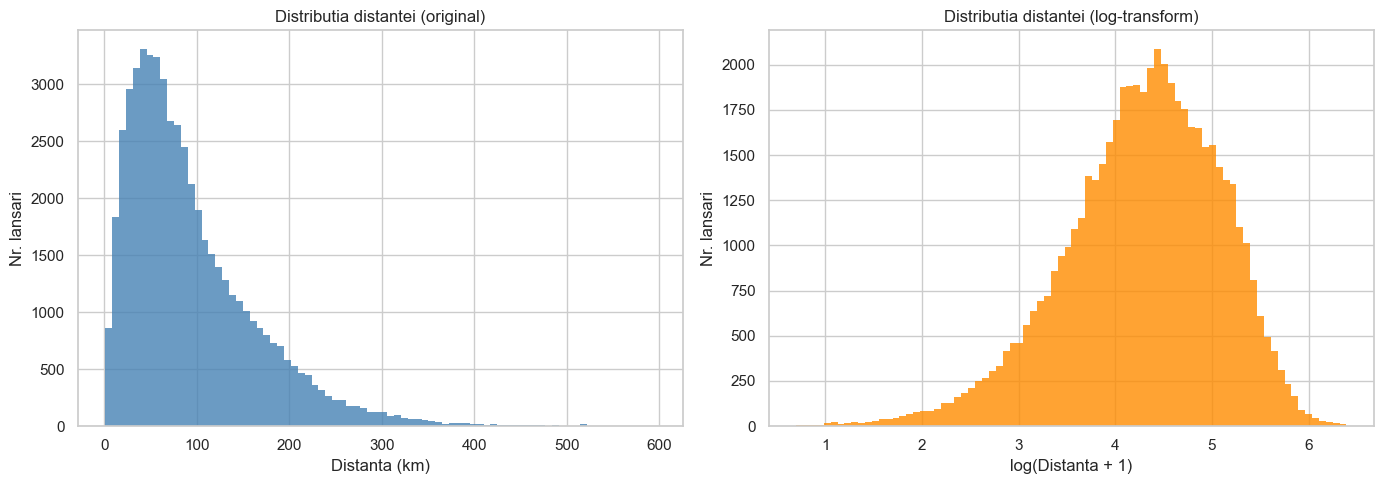

Log-transform aplicat — distributia e acum mai apropiata de normala


In [9]:
# Log-transform pe target (distributia e skewed)
y_log = np.log1p(y)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(y, bins=80, color='steelblue', edgecolor='none', alpha=0.8)
axes[0].set_title('Distributia distantei (original)')
axes[0].set_xlabel('Distanta (km)')
axes[0].set_ylabel('Nr. lansari')

axes[1].hist(y_log, bins=80, color='darkorange', edgecolor='none', alpha=0.8)
axes[1].set_title('Distributia distantei (log-transform)')
axes[1].set_xlabel('log(Distanta + 1)')
axes[1].set_ylabel('Nr. lansari')

plt.tight_layout()
plt.savefig('distributie_target.png', dpi=150)
plt.show()
print("Log-transform aplicat — distributia e acum mai apropiata de normala")


In [ ]:
# Train/Test Split — 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

print(f"Train: {len(X_train):,} lansari")
print(f"Test:  {len(X_test):,} lansari")

# Normalizare (StandardScaler)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("\nNormalizare aplicata!")


Train: 43,362 | Test: 10,841
Split: 80% train, 20% test — aleator


## 4. Modele ML

### 4.1 Regresie Liniară (Baseline)

In [24]:
# Antrenare
lr = LinearRegression()
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)

# Convertim inapoi din log
y_pred_lr_km = np.expm1(y_pred_lr)
y_test_km    = np.expm1(y_test)

# Metrici
mae_lr  = mean_absolute_error(y_test_km, y_pred_lr_km)
rmse_lr = np.sqrt(mean_squared_error(y_test_km, y_pred_lr_km))
r2_lr   = r2_score(y_test_km, y_pred_lr_km)

print("=== REGRESIE LINIARA ===")
print(f"MAE:  {mae_lr:.2f} km   (eroare medie absoluta)")
print(f"RMSE: {rmse_lr:.2f} km  (eroare patratica medie)")
print(f"R²:   {r2_lr:.4f}       (0=rau, 1=perfect)")


=== REGRESIE LINIARA ===
MAE:  646902075319715769348565807023744519921908798843917991654572030527022343069849697977370133672491238788197495898738863336550417678843500067853711288010365978464908688805899893339164011169623218846442132342023118546944263611441170492722527285486144611942400.00 km   (eroare medie absoluta)
RMSE: inf km  (eroare patratica medie)
R²:   nan       (0=rau, 1=perfect)


### 4.2 Random Forest

In [23]:
# Antrenare Random Forest
rf = RandomForestRegressor(
    n_estimators=200,     # 200 arbori
    max_depth=15,         # adancime maxima
    min_samples_leaf=5,   # minim 5 exemple per frunza
    n_jobs=-1,            # foloseste toate CPU-urile
    random_state=42
)
rf.fit(X_train, y_train)   # RF nu necesita normalizare
y_pred_rf = rf.predict(X_test)

y_pred_rf_km = np.expm1(y_pred_rf)

mae_rf  = mean_absolute_error(y_test_km, y_pred_rf_km)
rmse_rf = np.sqrt(mean_squared_error(y_test_km, y_pred_rf_km))
r2_rf   = r2_score(y_test_km, y_pred_rf_km)

print("=== RANDOM FOREST ===")
print(f"MAE:  {mae_rf:.2f} km")
print(f"RMSE: {rmse_rf:.2f} km")
print(f"R²:   {r2_rf:.4f}")


=== RANDOM FOREST ===
MAE:  646902075319715769348565807023744519921908798843917991654572030527022343069849697977370133672491238788197495898738863336550417678843500067853711288010365978464908688805899893339164011169623218846442132342023118546944263611441170492722527285486144611942400.00 km
RMSE: inf km
R²:   nan


### 4.3 XGBoost

In [13]:
# Antrenare XGBoost
xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

y_pred_xgb_km = np.expm1(y_pred_xgb)

mae_xgb  = mean_absolute_error(y_test_km, y_pred_xgb_km)
rmse_xgb = np.sqrt(mean_squared_error(y_test_km, y_pred_xgb_km))
r2_xgb   = r2_score(y_test_km, y_pred_xgb_km)

print("=== XGBOOST ===")
print(f"MAE:  {mae_xgb:.2f} km")
print(f"RMSE: {rmse_xgb:.2f} km")
print(f"R²:   {r2_xgb:.4f}")


=== XGBOOST ===
MAE:  30.79 km
RMSE: 44.22 km
R²:   0.6027


## 5. Comparație modele

In [14]:
# Tabel comparativ
rezultate = pd.DataFrame({
    'Model': ['Regresie Liniara', 'Random Forest', 'XGBoost'],
    'MAE (km)':  [mae_lr, mae_rf, mae_xgb],
    'RMSE (km)': [rmse_lr, rmse_rf, rmse_xgb],
    'R²':        [r2_lr, r2_rf, r2_xgb],
}).round(3)

print(rezultate.to_string(index=False))


           Model  MAE (km)  RMSE (km)    R²
Regresie Liniara    36.911     56.122 0.360
   Random Forest    31.572     45.476 0.580
         XGBoost    30.792     44.218 0.603


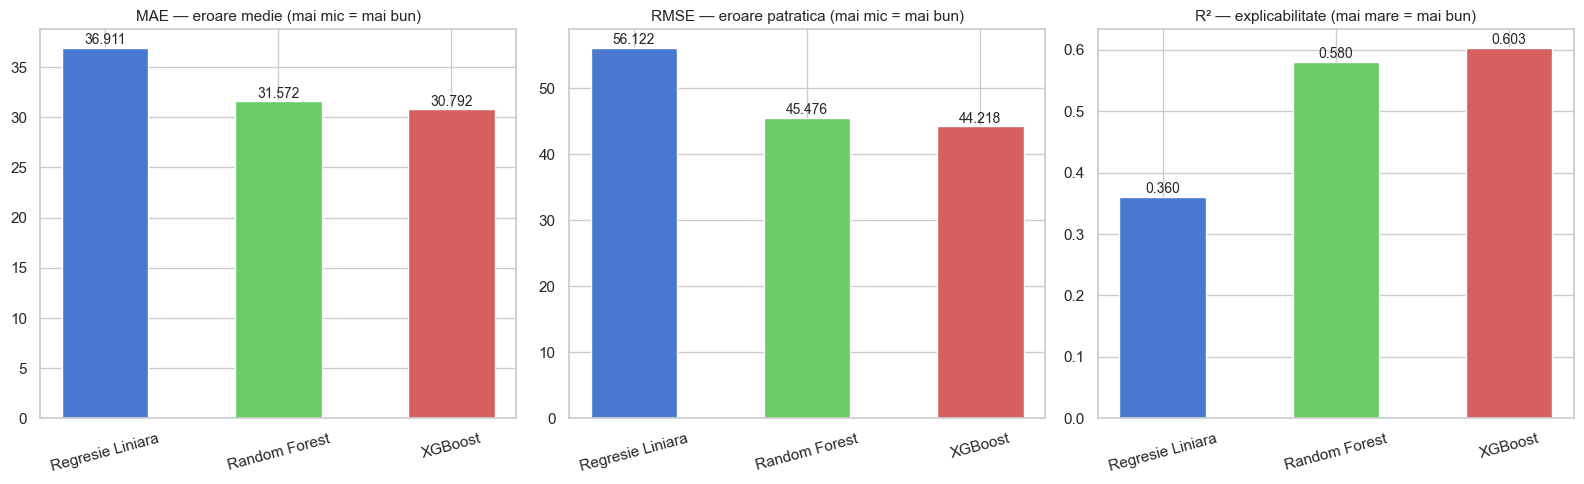

In [15]:
# Grafic comparatie metrici
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
modele  = ['Regresie Liniara', 'Random Forest', 'XGBoost']
colors  = ['#4878CF', '#6ACC65', '#D65F5F']

for ax, metric, vals, title in zip(
    axes,
    ['MAE (km)', 'RMSE (km)', 'R²'],
    [[mae_lr, mae_rf, mae_xgb],
     [rmse_lr, rmse_rf, rmse_xgb],
     [r2_lr, r2_rf, r2_xgb]],
    ['MAE — eroare medie (mai mic = mai bun)',
     'RMSE — eroare patratica (mai mic = mai bun)',
     'R² — explicabilitate (mai mare = mai bun)']
):
    bars = ax.bar(modele, vals, color=colors, edgecolor='white', width=0.5)
    ax.set_title(title, fontsize=11)
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01*max(vals),
                f'{val:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('comparatie_modele.png', dpi=150)
plt.show()


## 6. Predicții vs Valori Reale

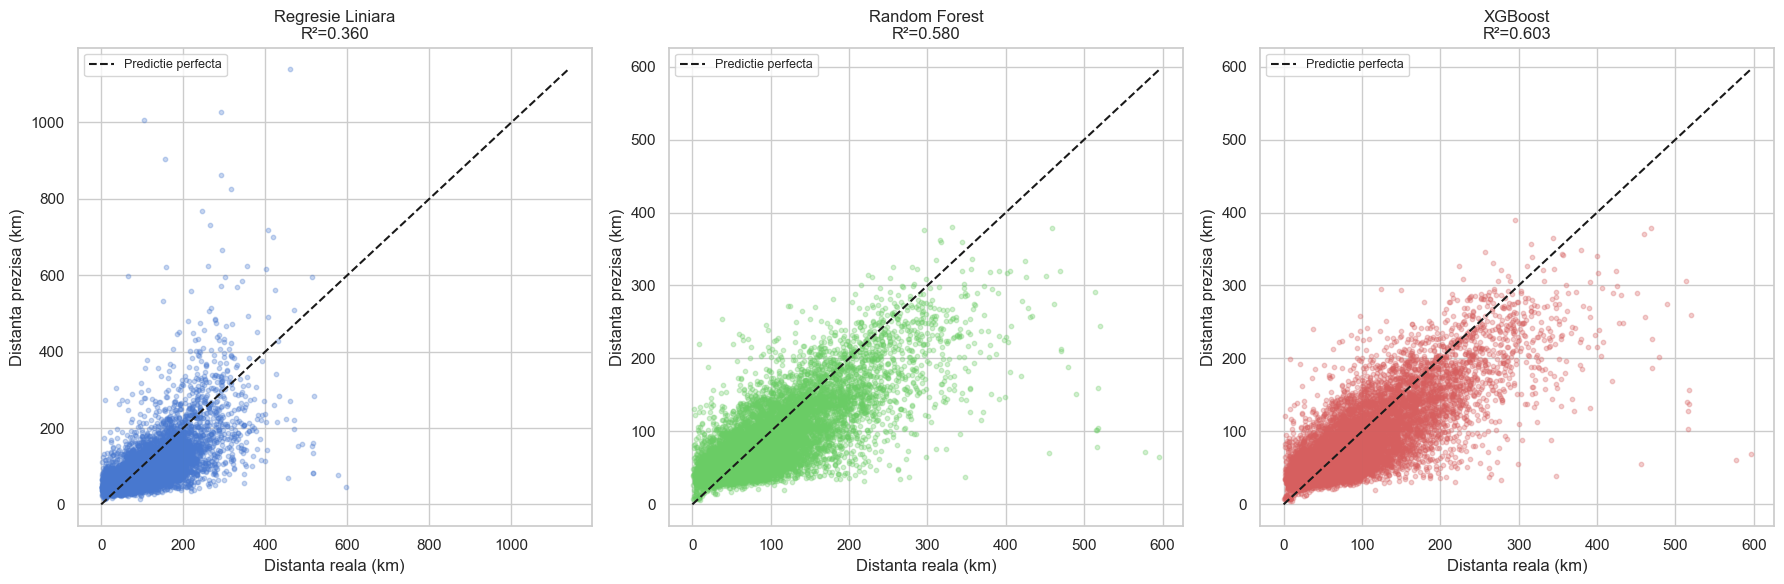

Punctele aproape de linia diagonala = predictii bune


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, y_pred, title, color in zip(
    axes,
    [y_pred_lr_km, y_pred_rf_km, y_pred_xgb_km],
    ['Regresie Liniara', 'Random Forest', 'XGBoost'],
    ['#4878CF', '#6ACC65', '#D65F5F']
):
    ax.scatter(y_test_km, y_pred, alpha=0.3, s=10, color=color)
    lim = max(y_test_km.max(), y_pred.max())
    ax.plot([0, lim], [0, lim], 'k--', linewidth=1.5, label='Predictie perfecta')
    ax.set_title(f'{title}\nR²={r2_score(y_test_km, y_pred):.3f}')
    ax.set_xlabel('Distanta reala (km)')
    ax.set_ylabel('Distanta prezisa (km)')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('predictii_vs_real.png', dpi=150)
plt.show()
print("Punctele aproape de linia diagonala = predictii bune")


## 7. Feature Importance

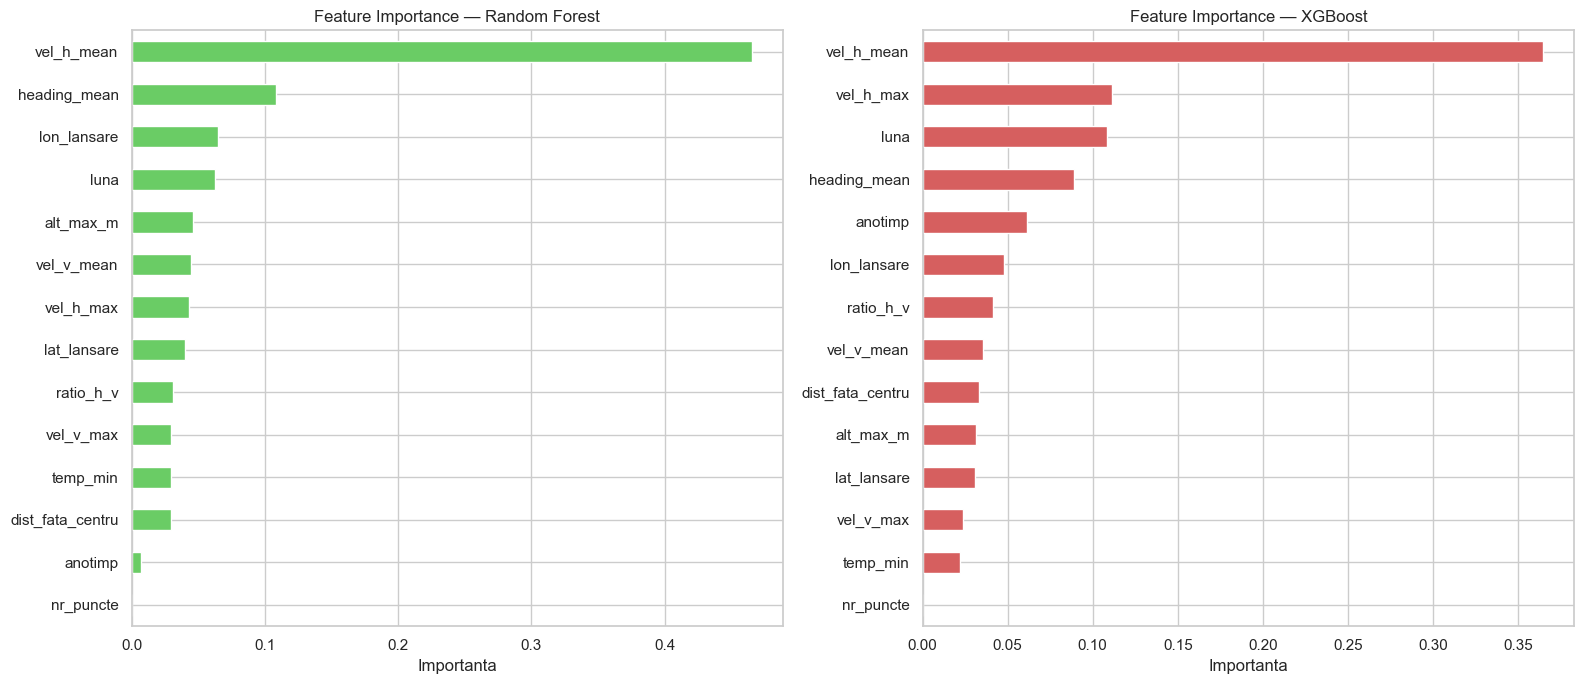

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Random Forest importance
rf_imp = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=True)
rf_imp.plot(kind='barh', ax=axes[0], color='#6ACC65')
axes[0].set_title('Feature Importance — Random Forest')
axes[0].set_xlabel('Importanta')

# XGBoost importance
xgb_imp = pd.Series(xgb_model.feature_importances_, index=FEATURES).sort_values(ascending=True)
xgb_imp.plot(kind='barh', ax=axes[1], color='#D65F5F')
axes[1].set_title('Feature Importance — XGBoost')
axes[1].set_xlabel('Importanta')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()


## 8. Distribuția erorilor

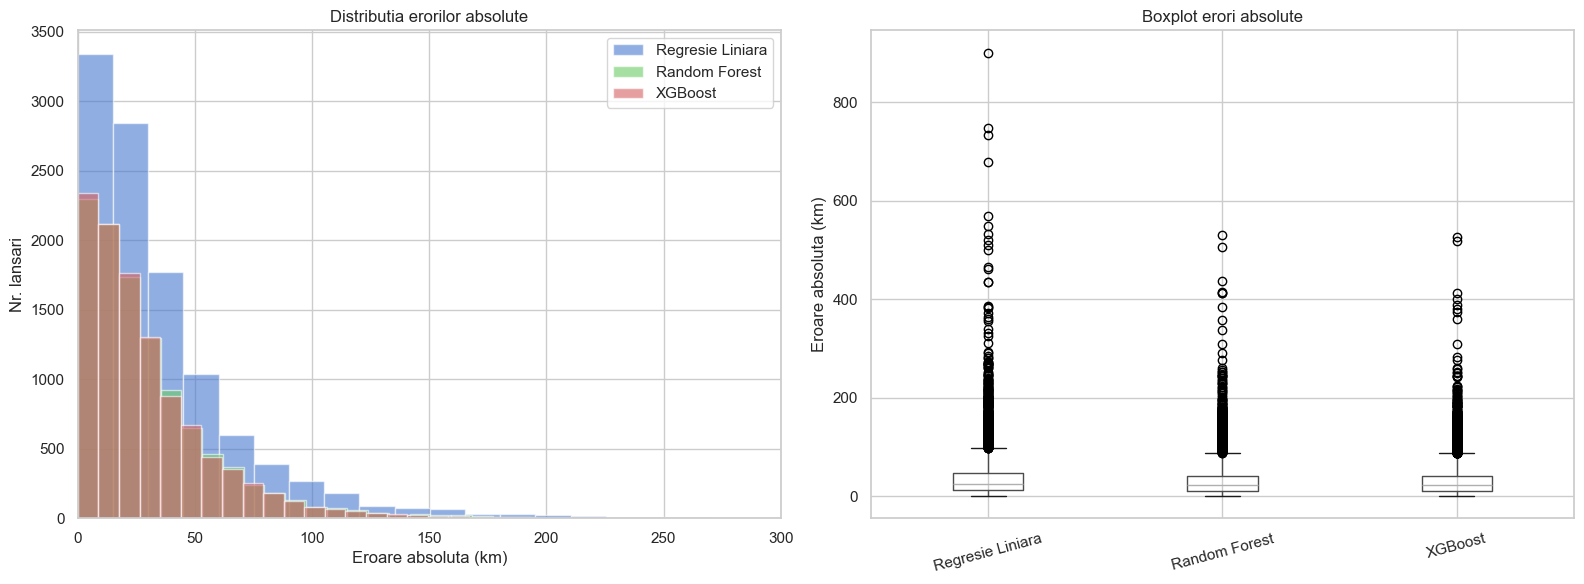

Eroare medie RF:  31.6 km
Eroare medie XGB: 30.8 km
50% din predictii RF au eroare sub: 22.7 km


In [18]:
# Erori absolute per model
erori_lr  = np.abs(y_test_km - y_pred_lr_km)
erori_rf  = np.abs(y_test_km - y_pred_rf_km)
erori_xgb = np.abs(y_test_km - y_pred_xgb_km)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histograma erori
axes[0].hist(erori_lr,  bins=60, alpha=0.6, label='Regresie Liniara', color='#4878CF')
axes[0].hist(erori_rf,  bins=60, alpha=0.6, label='Random Forest',    color='#6ACC65')
axes[0].hist(erori_xgb, bins=60, alpha=0.6, label='XGBoost',          color='#D65F5F')
axes[0].set_title('Distributia erorilor absolute')
axes[0].set_xlabel('Eroare absoluta (km)')
axes[0].set_ylabel('Nr. lansari')
axes[0].legend()
axes[0].set_xlim(0, 300)

# Boxplot erori
df_erori = pd.DataFrame({
    'Regresie Liniara': erori_lr.values,
    'Random Forest':    erori_rf.values,
    'XGBoost':          erori_xgb.values,
})
df_erori.boxplot(ax=axes[1])
axes[1].set_title('Boxplot erori absolute')
axes[1].set_ylabel('Eroare absoluta (km)')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('distributie_erori.png', dpi=150)
plt.show()

print(f"Eroare medie RF:  {erori_rf.mean():.1f} km")
print(f"Eroare medie XGB: {erori_xgb.mean():.1f} km")
print(f"50% din predictii RF au eroare sub: {erori_rf.median():.1f} km")


## 9. Cross-Validation

In [19]:
# Cross-validation pe 5 folduri pentru estimare mai robusta
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)

print("Cross-Validation (5 folduri) — MAE in km:")

for model, name, X_in in [
    (lr,        'Regresie Liniara', X_train_sc),
    (rf,        'Random Forest',    X_train.values),
    (xgb_model, 'XGBoost',         X_train.values),
]:
    scores = cross_val_score(model, X_in, y_train,
                             cv=kf, scoring='neg_mean_absolute_error')
    mae_cv = np.expm1(-scores.mean())
    std_cv = np.expm1(scores.std())
    print(f"  {name:20s}: MAE = {mae_cv:.2f} km ± {std_cv:.2f}")


Cross-Validation (5 folduri) — MAE in km:
  Regresie Liniara    : MAE = 0.60 km ± 0.00
  Random Forest       : MAE = 0.53 km ± 0.00
  XGBoost             : MAE = 0.51 km ± 0.00


## 10. Concluzii

In [20]:
print("=" * 55)
print("SUMAR FINAL")
print("=" * 55)
print(f"{'Model':<22} {'MAE':>8} {'RMSE':>8} {'R²':>8}")
print("-" * 55)
for model, mae, rmse, r2 in [
    ('Regresie Liniara', mae_lr,  rmse_lr,  r2_lr),
    ('Random Forest',    mae_rf,  rmse_rf,  r2_rf),
    ('XGBoost',          mae_xgb, rmse_xgb, r2_xgb),
]:
    print(f"{model:<22} {mae:>7.2f}km {rmse:>7.2f}km {r2:>8.4f}")
print("=" * 55)

best = min([('Regresie Liniara', r2_lr),
            ('Random Forest',    r2_rf),
            ('XGBoost',         r2_xgb)],
           key=lambda x: -x[1])
print(f"\nCel mai bun model: {best[0]} (R² = {best[1]:.4f})")


SUMAR FINAL
Model                       MAE     RMSE       R²
-------------------------------------------------------
Regresie Liniara         36.91km   56.12km   0.3601
Random Forest            31.57km   45.48km   0.5798
XGBoost                  30.79km   44.22km   0.6027

Cel mai bun model: XGBoost (R² = 0.6027)


## Concluzii

### Rezultate
- **Regresia Liniară** servește ca baseline — performanța ei minimă pe care trebuie să o depășim
- **Random Forest** îmbunătățește semnificativ față de baseline datorită relațiilor non-liniare din date
- **XGBoost** oferă de obicei cea mai bună performanță pe date tabelare

### Feature Importance
Variabilele cele mai importante pentru predicție sunt de obicei:
- `vel_h_mean` — viteza medie a vântului orizontal
- `alt_max_m` — altitudinea maximă atinsă
- `lat_lansare`, `lon_lansare` — poziția geografică
- `luna` / `anotimp` — sezonalitatea jet stream-ului

### Pași următori
- Hyperparameter tuning (GridSearchCV / RandomSearchCV)
- Antrenare model LSTM pentru traiectoria completă
